# 02 - Analyse Exploratoire des Données (EDA)

## Objectifs
- Analyse univariée : distribution de chaque variable
- Analyse bivariée : relations entre variables et la survie
- Analyse multivariée : interactions complexes
- Corrélations
- **Insights** pour guider la modélisation

In [60]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Configuration
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [61]:
# Charger les données
df = pd.read_csv('../data/raw/train.csv')
print(f"Dataset chargé")

Dataset chargé


---
## 1. Analyse Univariée

Étudier la distribution de chaque variable individuellement.

### 1.1 Variable cible : Survived


Taux de survie : 38.4%


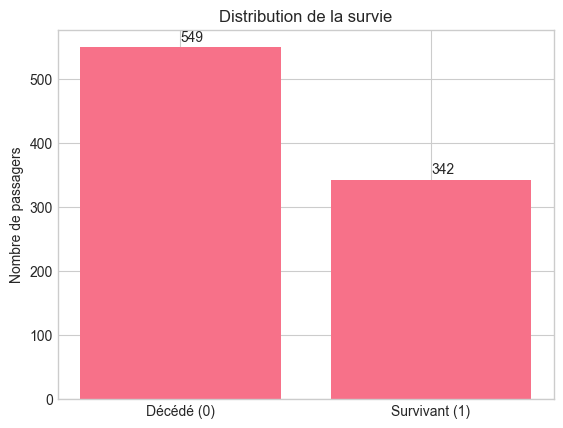

In [62]:
fig, axes = plt.subplots(1, 1)

survived_counts = df['Survived'].value_counts()
axes.bar(['Décédé (0)', 'Survivant (1)'], survived_counts.values)
axes.set_ylabel('Nombre de passagers')
axes.set_title('Distribution de la survie')
for i, v in enumerate(survived_counts.values):
    axes.text(i, v + 10, str(v))

print(f"\nTaux de survie : {df['Survived'].mean()*100:.1f}%")

### 1.2 Variables numériques

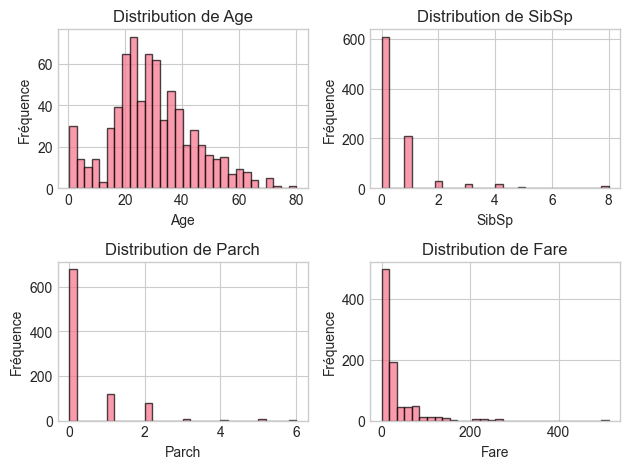

In [63]:
numerical_cols = ['Age', 'SibSp', 'Parch', 'Fare']

fig, axes = plt.subplots(2, 2)

for i, col in enumerate(numerical_cols):
    axes[i//2, i%2].hist(df[col].dropna(), bins=30, edgecolor='black', alpha=0.7)
    axes[i//2, i%2].set_xlabel(col)
    axes[i//2, i%2].set_ylabel('Fréquence')
    axes[i//2, i%2].set_title(f'Distribution de {col}')

plt.tight_layout()
plt.show()

In [64]:
print("Statistiques des variables numériques :")
print("="*60)

for col in numerical_cols:
    data = df[col].dropna()
    print(f"\n{col}:")
    print(f"  Moyenne: {data.mean():.2f}")
    print(f"  Médiane: {data.median():.2f}")
    print(f"  Écart-type: {data.std():.2f}")
    print(f"  Min/Max: {data.min():.2f} / {data.max():.2f}")

Statistiques des variables numériques :

Age:
  Moyenne: 29.70
  Médiane: 28.00
  Écart-type: 14.53
  Min/Max: 0.42 / 80.00

SibSp:
  Moyenne: 0.52
  Médiane: 0.00
  Écart-type: 1.10
  Min/Max: 0.00 / 8.00

Parch:
  Moyenne: 0.38
  Médiane: 0.00
  Écart-type: 0.81
  Min/Max: 0.00 / 6.00

Fare:
  Moyenne: 32.20
  Médiane: 14.45
  Écart-type: 49.69
  Min/Max: 0.00 / 512.33


### 1.3 Variables catégorielles

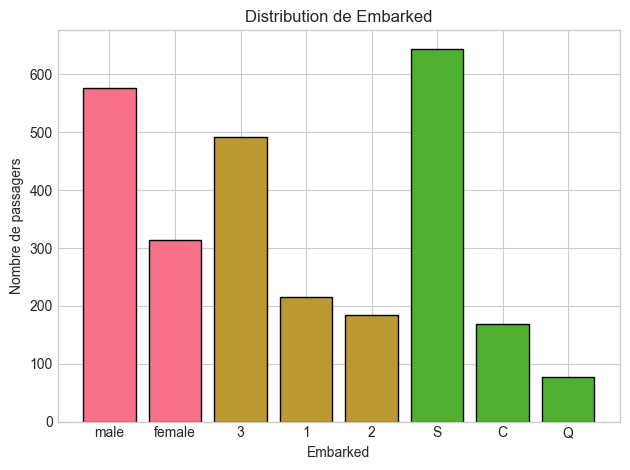

In [65]:
categorical_cols = ['Sex', 'Pclass', 'Embarked']

fig, axes = plt.subplots(1, 1)

for i, col in enumerate(categorical_cols):
    counts = df[col].value_counts()
    axes.bar(counts.index.astype(str), counts.values, edgecolor='black')
    axes.set_xlabel(col)
    axes.set_ylabel('Nombre de passagers')
    axes.set_title(f'Distribution de {col}')

plt.tight_layout()
plt.show()

---
## 2. Analyse Bivariée : Relations avec la survie

### 2.1 Survie par Sexe

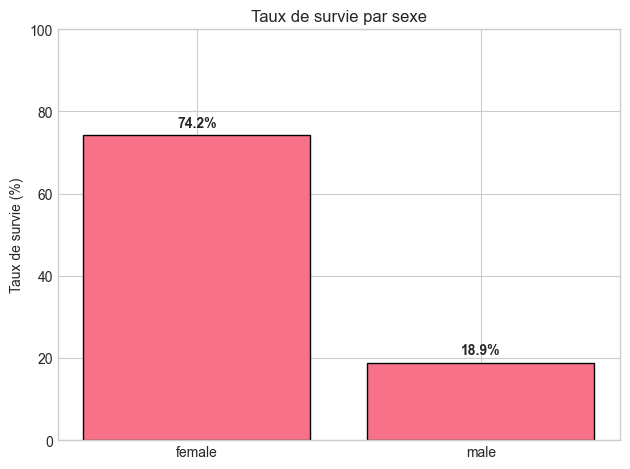

In [71]:
fig, axes = plt.subplots(1, 1)

survival_by_sex = df.groupby('Sex')['Survived'].mean() * 100
axes.bar(survival_by_sex.index, survival_by_sex.values, edgecolor='black')
axes.set_ylabel('Taux de survie (%)')
axes.set_title('Taux de survie par sexe')
axes.set_ylim(0, 100)
for i, v in enumerate(survival_by_sex.values):
    axes.text(i, v + 2, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

### 2.2 Survie par Classe

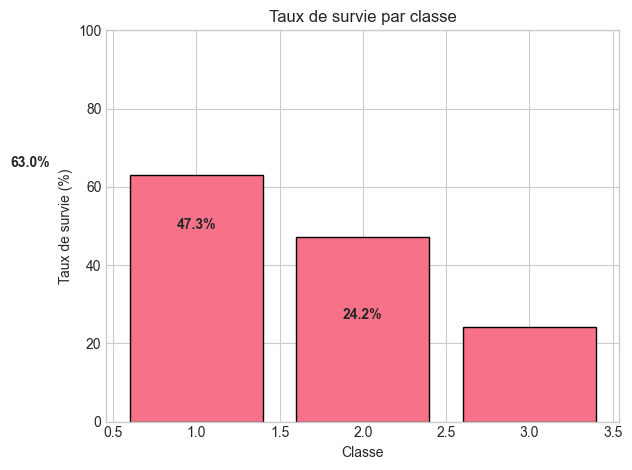

In [75]:
fig, axes = plt.subplots(1, 1)

survival_by_class = df.groupby('Pclass')['Survived'].mean() * 100
axes.bar(survival_by_class.index, survival_by_class.values, edgecolor='black')
axes.set_xlabel('Classe')
axes.set_ylabel('Taux de survie (%)')
axes.set_title('Taux de survie par classe')
axes.set_ylim(0, 100)
for i, v in enumerate(survival_by_class.values):
    axes.text(i, v + 2, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

### 2.3 Survie par Âge


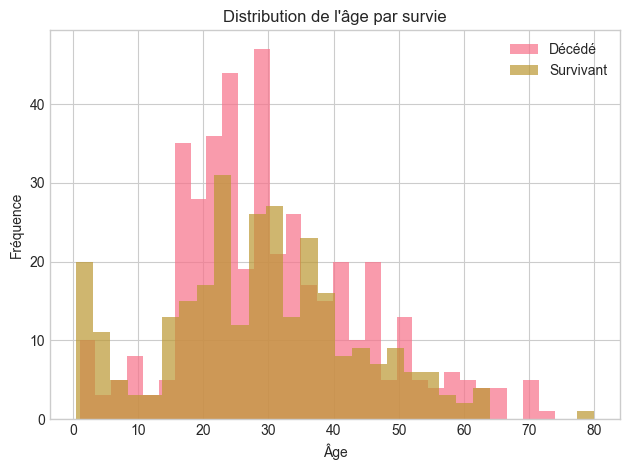

In [74]:
fig, axes = plt.subplots(1, 1)

df[df['Survived'] == 0]['Age'].hist(ax=axes, bins=30, alpha=0.7, 
                                     label='Décédé')
df[df['Survived'] == 1]['Age'].hist(ax=axes, bins=30, alpha=0.7, 
                                     label='Survivant')
axes.set_xlabel('Âge')
axes.set_ylabel('Fréquence')
axes.set_title('Distribution de l\'âge par survie')
axes.legend()

plt.tight_layout()
plt.show()

### 2.4 Survie par Port d'embarquement

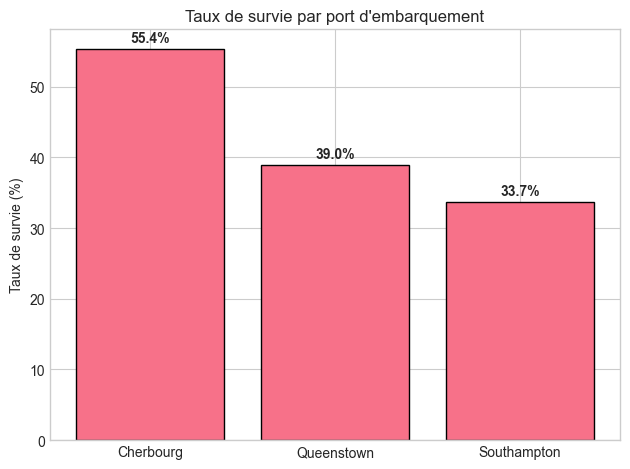

In [76]:
fig, axes = plt.subplots(1, 1)

survival_by_embarked = df.groupby('Embarked')['Survived'].mean() * 100
port_names = {'C': 'Cherbourg', 'Q': 'Queenstown', 'S': 'Southampton'}
survival_by_embarked.index = survival_by_embarked.index.map(port_names)

axes.bar(survival_by_embarked.index, survival_by_embarked.values, edgecolor='black')
axes.set_ylabel('Taux de survie (%)')
axes.set_title('Taux de survie par port d\'embarquement')
for i, v in enumerate(survival_by_embarked.values):
    axes.text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()